In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from src.pipeline import ResearchPipeline
from src.factor import FactorAttribution
from src.strategies.momentum import MomentumStrategy

In [3]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [4]:
strategy = MomentumStrategy(
    lookback=13,
    top_n=3,
    bottom_n=3
)

pipeline = ResearchPipeline(
    strategy=strategy
)

results = pipeline.run(prices)

In [5]:
strategy_returns = results["strategy_returns"]

weekly_returns = results["weekly_returns"]

strategy_returns.head()

Date
2000-01-07    0.0
2000-01-14    0.0
2000-01-21    0.0
2000-01-28    0.0
2000-02-04    0.0
Freq: W-FRI, dtype: float64

In [6]:
factor = FactorAttribution()

benchmark_returns = factor.benchmark_returns(
    weekly_returns
)

benchmark_returns.head()

Date
2000-01-07         NaN
2000-01-14   -0.011549
2000-01-21    0.022302
2000-01-28   -0.074450
2000-02-04    0.077549
Freq: W-FRI, dtype: float64

In [7]:
summary = factor.summary(
    strategy_returns,
    benchmark_returns
)

summary

Alpha                0.127720
Beta                -0.135252
Correlation         -0.095925
R Squared            0.009202
Tracking Error       0.392447
Information Ratio   -0.323592
dtype: float64

In [9]:
aligned = factor._align_returns(
    strategy_returns,
    benchmark_returns
)

print("Shape:", aligned.shape)
print("\nMissing values:")
print(aligned.isna().sum())

print("\nInfinite values:")
print(
    aligned.isin([float("inf"), float("-inf")]).sum()
)

print("\nBenchmark variance:")
print(aligned["Benchmark"].var())

print("\nStrategy variance:")
print(aligned["Strategy"].var())

aligned.head(15)

Shape: (1363, 2)

Missing values:
Strategy     0
Benchmark    0
dtype: int64

Infinite values:
Strategy     0
Benchmark    0
dtype: int64

Benchmark variance:
0.0009089440591649837

Strategy variance:
0.0018070108213271699


,Strategy,Benchmark
Date,,
2000-01-14,0.000000,-0.011549
2000-01-21,0.000000,0.022302
2000-01-28,0.000000,-0.074450
2000-02-04,0.000000,0.077549
2000-02-11,0.000000,0.002586
2000-02-18,0.000000,-0.003619
2000-02-25,0.000000,-0.026009
2000-03-03,0.000000,0.026577
2000-03-10,0.000000,0.131384


In [10]:
print("Strategy:")
print(strategy_returns.describe())

print("\nBenchmark:")
print(benchmark_returns.describe())

Strategy:
count    1364.000000
mean        0.001871
std         0.042493
min        -0.174256
25%        -0.020983
50%         0.001375
75%         0.024969
max         0.200475
dtype: float64

Benchmark:
count    1363.000000
mean        0.004315
std         0.030149
min        -0.154140
25%        -0.011489
50%         0.004781
75%         0.021425
max         0.148064
dtype: float64


In [11]:
rolling_beta = factor.rolling_beta(
    strategy_returns,
    benchmark_returns
)

rolling_beta.head()

Date
2000-01-14   NaN
2000-01-21   NaN
2000-01-28   NaN
2000-02-04   NaN
2000-02-11   NaN
Freq: W-FRI, dtype: float64

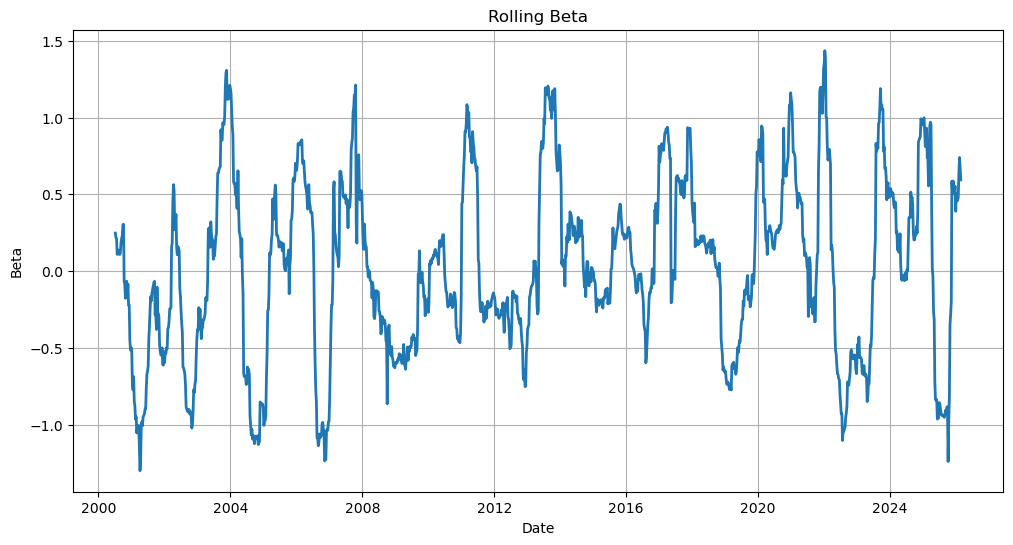

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_beta,
    linewidth=2
)

plt.title("Rolling Beta")
plt.xlabel("Date")
plt.ylabel("Beta")

plt.grid(True)

plt.show()

In [13]:
active_returns = factor.active_returns(
    strategy_returns,
    benchmark_returns
)

active_returns.head()

Date
2000-01-14    0.011549
2000-01-21   -0.022302
2000-01-28    0.074450
2000-02-04   -0.077549
2000-02-11   -0.002586
Freq: W-FRI, dtype: float64

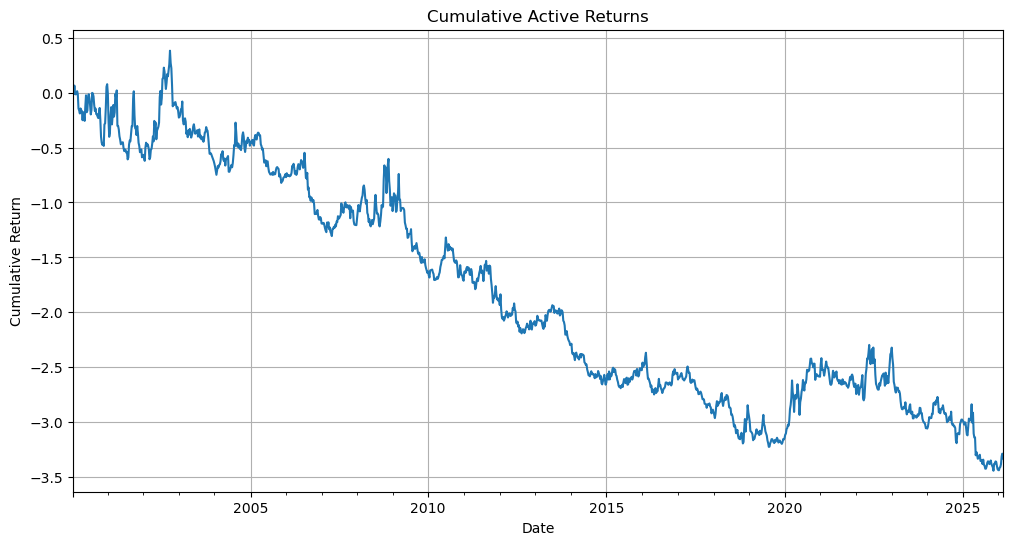

In [14]:
plt.figure(figsize=(12, 6))

active_returns.cumsum().plot()

plt.title("Cumulative Active Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.grid(True)

plt.show()

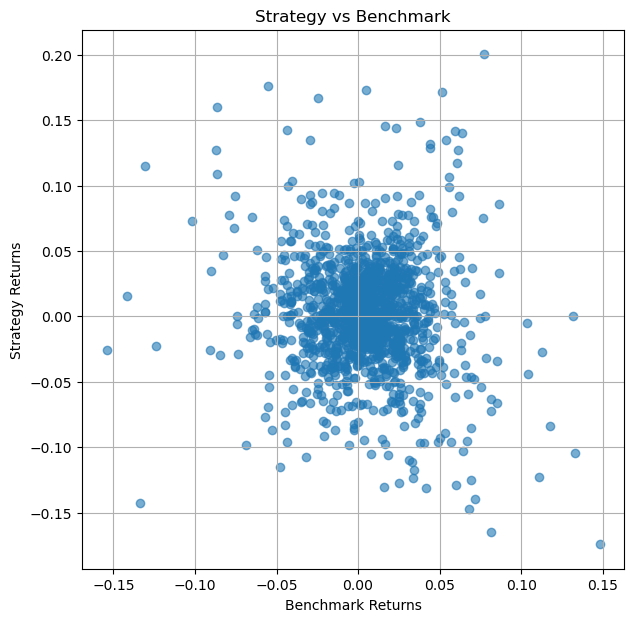

In [15]:
plt.figure(figsize=(7, 7))

plt.scatter(
    benchmark_returns,
    strategy_returns,
    alpha=0.6
)

plt.xlabel("Benchmark Returns")
plt.ylabel("Strategy Returns")
plt.title("Strategy vs Benchmark")

plt.grid(True)

plt.show()

In [16]:
os.makedirs(
    "../results",
    exist_ok=True
)

summary.to_csv(
    "../results/factor_summary.csv"
)

print("Factor attribution summary saved successfully.")

Factor attribution summary saved successfully.
